In [31]:
# --- Imports 

import numpy as np
import pandas as pd
from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestClassifier

In [32]:
#from google.colab import drive
#drive.mount('/content/drive')

In [33]:
# --- Loading all the datasets

# Train dataset
train_dataset = pd.read_csv('data/train_radiomics_hipocamp.csv')
# Test dataset
test_dataset = pd.read_csv('data/test_radiomics_hipocamp.csv')

In [34]:
# --- Exploring the train dataset

print(f"DS SHAPE\n{train_dataset.shape}\n")

print(f"DATA TYPE\n{train_dataset.dtypes.value_counts()}\n")

object_columns = train_dataset.select_dtypes(include='object').columns
print(f"OBJECT COLUMNS\n{object_columns.tolist()}\n")

missing_summary = train_dataset.isnull().sum()
print(f"MISSING VALUES\n{(missing_summary > 0).sum()}\n")

print(train_dataset['Transition'].value_counts(normalize=True))
unique_counts = train_dataset.nunique()

print(f"\nUNIQUE VALUE COLUMN\n{(unique_counts == 1).sum()}")

DS SHAPE
(305, 2181)

DATA TYPE
float64    2014
int64       147
object       20
Name: count, dtype: int64

OBJECT COLUMNS
['ID', 'Image', 'Mask', 'diagnostics_Versions_PyRadiomics', 'diagnostics_Versions_Numpy', 'diagnostics_Versions_SimpleITK', 'diagnostics_Versions_PyWavelet', 'diagnostics_Versions_Python', 'diagnostics_Configuration_Settings', 'diagnostics_Configuration_EnabledImageTypes', 'diagnostics_Image-original_Hash', 'diagnostics_Image-original_Spacing', 'diagnostics_Image-original_Size', 'diagnostics_Mask-original_Hash', 'diagnostics_Mask-original_Spacing', 'diagnostics_Mask-original_Size', 'diagnostics_Mask-original_BoundingBox', 'diagnostics_Mask-original_CenterOfMassIndex', 'diagnostics_Mask-original_CenterOfMass', 'Transition']

MISSING VALUES
0

Transition
CN-CN      0.314754
MCI-MCI    0.232787
MCI-AD     0.222951
AD-AD      0.196721
CN-MCI     0.032787
Name: proportion, dtype: float64

UNIQUE VALUE COLUMN
159


In [35]:
# --- Removing columns with irrelevant information

# Getting all columns whose value is an object
obj_col = train_dataset.select_dtypes(include='object').columns

# Storing in a list the columns that have the same number of unique values as the number of rows
# This means that the column is a unique identifier and probably should be dropped
unique_cols = [col for col in obj_col if train_dataset[col].nunique() == train_dataset.shape[0]]

print(f"UNIQUE COLUMNS\n{unique_cols}\n")

# The following features might actually be useful:
cols_to_keep = [
    'diagnostics_Mask-original_BoundingBox',
    'diagnostics_Mask-original_CenterOfMassIndex',
    'diagnostics_Mask-original_CenterOfMass'
]

# removing last 3 columns from the 'unique_cols' - we don't want to drop them
unique_cols = [col for col in unique_cols if col not in cols_to_keep]

# Dropping the columns stored in the unique_cols list
train_dataset.drop(columns=unique_cols, inplace=True)

# Dropping them from the test dataset as well
test_dataset.drop(columns=unique_cols, inplace=True)

pd.set_option('display.max_colwidth', None)
display(train_dataset['diagnostics_Mask-original_BoundingBox'])
display(train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].head())
display(train_dataset['diagnostics_Mask-original_CenterOfMass'].head())
print(f"\nDS SHAPE\n{train_dataset.shape}")

UNIQUE COLUMNS
['ID', 'Image', 'Mask', 'diagnostics_Image-original_Hash', 'diagnostics_Mask-original_Hash', 'diagnostics_Mask-original_BoundingBox', 'diagnostics_Mask-original_CenterOfMassIndex', 'diagnostics_Mask-original_CenterOfMass']



0      (103, 113, 93, 36, 30, 71)
1       (81, 127, 93, 47, 16, 73)
2       (77, 119, 89, 49, 30, 81)
3       (93, 102, 90, 41, 29, 78)
4       (87, 119, 91, 40, 27, 75)
                  ...            
300     (88, 118, 89, 41, 25, 78)
301    (103, 103, 93, 38, 27, 70)
302     (80, 131, 89, 48, 17, 82)
303     (93, 103, 91, 40, 31, 75)
304     (95, 126, 93, 40, 22, 74)
Name: diagnostics_Mask-original_BoundingBox, Length: 305, dtype: object

0    (121.94230227976358, 129.27272727272728, 128.40402476780187)
1    (107.06170458927883, 135.28088443244633, 128.27458542229078)
2     (103.3640972118682, 135.28164604144922, 128.98628298792306)
3     (116.29827315541601, 118.67431469629271, 129.3098659582176)
4    (108.26561977948546, 132.05462746408287, 127.67206815903775)
Name: diagnostics_Mask-original_CenterOfMassIndex, dtype: object

0    (121.94230227976358, 129.27272727272728, 128.40402476780187)
1    (107.06170458927883, 135.28088443244633, 128.27458542229078)
2     (103.3640972118682, 135.28164604144922, 128.98628298792306)
3     (116.29827315541601, 118.67431469629271, 129.3098659582176)
4    (108.26561977948546, 132.05462746408287, 127.67206815903775)
Name: diagnostics_Mask-original_CenterOfMass, dtype: object


DS SHAPE
(305, 2176)


In [36]:
# --- Checking if 'diagnostics_Mask-original_CenterOfMassIndex' and 'diagnostics_Mask-original_CenterOfMass' are the same
# They are, we can drop one of them

print(f"DS SHAPE\n{train_dataset.shape}\n")
are_equal = ((train_dataset['diagnostics_Mask-original_CenterOfMassIndex'] == train_dataset['diagnostics_Mask-original_CenterOfMass']).all())
print(f"ARE EQUAL: {are_equal}\n")

# They are the same, so we can drop one of them
train_dataset.drop('diagnostics_Mask-original_CenterOfMass', axis=1, inplace=True)
test_dataset.drop('diagnostics_Mask-original_CenterOfMass', axis=1, inplace=True)
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2176)

ARE EQUAL: True

DS SHAPE
(305, 2175)


In [37]:
# --- Transfoming the 'diagnostics_Mask-original_BoundingBox' feature into useful data

print(f"DS SHAPE\n{train_dataset.shape}\n")

# Splitting the string into 6 different columns
# probably x,y,z,width,height,depth -> most common

train_dataset['diagnostics_Mask-original_BoundingBox'] = train_dataset['diagnostics_Mask-original_BoundingBox'].str.replace('(', '').str.replace(')', '')
train_dataset['diagnostics_Mask-original_BoundingBox'] = train_dataset['diagnostics_Mask-original_BoundingBox'].str.split(',').apply(lambda x: [int(i) for i in x])
train_dataset[['x', 'y', 'z', 'width', 'height', 'depth']] = pd.DataFrame(train_dataset['diagnostics_Mask-original_BoundingBox'].tolist(), index=train_dataset.index)
train_dataset.drop('diagnostics_Mask-original_BoundingBox', axis=1, inplace=True)

# Doing the same for the test dataset
test_dataset['diagnostics_Mask-original_BoundingBox'] = test_dataset['diagnostics_Mask-original_BoundingBox'].str.replace('(', '').str.replace(')', '')
test_dataset['diagnostics_Mask-original_BoundingBox'] = test_dataset['diagnostics_Mask-original_BoundingBox'].str.split(',').apply(lambda x: [int(i) for i in x])
test_dataset[['x', 'y', 'z', 'width', 'height', 'depth']] = pd.DataFrame(test_dataset['diagnostics_Mask-original_BoundingBox'].tolist(), index=test_dataset.index)
test_dataset.drop('diagnostics_Mask-original_BoundingBox', axis=1, inplace=True)

# Calculating the volume of the bounding box
train_dataset['volume'] = train_dataset['width'] * train_dataset['height'] * train_dataset['depth']
test_dataset['volume'] = test_dataset['width'] * test_dataset['height'] * test_dataset['depth']
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2175)

DS SHAPE
(305, 2181)


In [38]:
# --- Transfoming the 'diagnostics_Mask-original_CenterOfMassIndex' feature into useful data

print(f"DS SHAPE\n{train_dataset.shape}\n")

# Splitting the string into 3 different columns
# x_center, y_center, z_center

train_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.replace('(', '').str.replace(')', '')
train_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.split(',').apply(lambda x: [float(i) for i in x])
train_dataset[['x_center', 'y_center', 'z_center']] = pd.DataFrame(train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].tolist(), index=train_dataset.index)
train_dataset.drop('diagnostics_Mask-original_CenterOfMassIndex', axis=1, inplace=True)

# Doing the same for the test dataset
test_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = test_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.replace('(', '').str.replace(')', '')
test_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = test_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.split(',').apply(lambda x: [float(i) for i in x])
test_dataset[['x_center', 'y_center', 'z_center']] = pd.DataFrame(test_dataset['diagnostics_Mask-original_CenterOfMassIndex'].tolist(), index=test_dataset.index)
test_dataset.drop('diagnostics_Mask-original_CenterOfMassIndex', axis=1, inplace=True)

# Calculating the distance from the center of mass to the bounding box
train_dataset['distance'] = np.sqrt((train_dataset['x'] - train_dataset['x_center'])**2 + (train_dataset['y'] - train_dataset['y_center'])**2 + (train_dataset['z'] - train_dataset['z_center'])**2)
test_dataset['distance'] = np.sqrt((test_dataset['x'] - test_dataset['x_center'])**2 + (test_dataset['y'] - test_dataset['y_center'])**2 + (test_dataset['z'] - test_dataset['z_center'])**2)
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2181)

DS SHAPE
(305, 2184)


In [39]:
# --- Dropping constant features - features that have the same value for all rows
train_dataset = train_dataset.loc[:, (train_dataset != train_dataset.iloc[0]).any()]

# Dropping the same columns on the test dataset
test_dataset = test_dataset[train_dataset.drop(columns='Transition').columns]

print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2025)


In [40]:
# --- Checking all unique values in the Transition column
train_dataset['Transition'].value_counts()
# Dataset is extremely UNBALANCED

Transition
CN-CN      96
MCI-MCI    71
MCI-AD     68
AD-AD      60
CN-MCI     10
Name: count, dtype: int64

In [41]:
# --- Using encoding to transform the target columns into numeric values

replace_map = {'Transition': {'CN-CN': 1, 'AD-AD': 2, 'CN-MCI': 3, 'MCI-AD': 4, 'MCI-MCI': 5}}
print(f"TRANSITION BEFORE ENCODING:\n{train_dataset['Transition'].head()}\n")
train_dataset = train_dataset.replace(replace_map)
test_dataset = test_dataset.replace(replace_map)
print(f"TRANSITION AFTER ENCODING:\n{train_dataset['Transition'].head()}")

TRANSITION BEFORE ENCODING:
0     CN-CN
1     CN-CN
2     AD-AD
3    CN-MCI
4     CN-CN
Name: Transition, dtype: object

TRANSITION AFTER ENCODING:
0    1
1    1
2    2
3    3
4    1
Name: Transition, dtype: int64


C:\Users\Utilizador\AppData\Local\Temp\ipykernel_10856\2667512575.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_dataset = train_dataset.replace(replace_map)


In [42]:
train_dataset['Transition'].value_counts()

Transition
1    96
5    71
4    68
2    60
3    10
Name: count, dtype: int64

In [43]:
# --- Dropping non-target columns with the same info (correlation = 1 between them)

print(f"DS SHAPE\n{train_dataset.shape}\n")
target_column = 'Transition'
# Calculating the correlation matrix (excluding the target column)
train_dataset_tmp = train_dataset
corr_matrix_train = train_dataset_tmp.drop(columns=[target_column]).corr().abs()

# Upper triangle matrix of correlations
upper = corr_matrix_train.where(np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool))

# Finding index of feature columns with correlation equal to 1
threshold = 1.0
to_drop = [column for column in upper.columns if any(upper[column] >= threshold)] # for some reason there are columns with correlation > 1.0
print("DROPPING " + str(len(to_drop)) + " COLUMNS\n")

# Dropping the columns
train_dataset = train_dataset.drop(columns=to_drop)
test_dataset = test_dataset.drop(columns=to_drop)
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2025)

DROPPING 137 COLUMNS

DS SHAPE
(305, 1888)


In [44]:
## --- Dropping columns with low correlation with the target column (<0.005)

#print(f"DS SHAPE\n{train_dataset.shape}\n")
#corr_matrix = train_dataset.corr()
#corr_target = corr_matrix['Transition'].abs()
#uncorr_cols = []
#for i in range(len(corr_target)):
#  if corr_target.iloc[i] < 0.005:
#    uncorr_cols.append(corr_matrix.columns[i])
#
## Dropping the columns stored in the uncorr_cols list
#n_cols_before = len(train_dataset.columns)
#train_dataset.drop(uncorr_cols, axis=1, inplace=True)
#test_dataset.drop(uncorr_cols, axis=1, inplace=True)
#n_cols_after = len(train_dataset.columns)
#
#print("DROPPED " + str(n_cols_before-n_cols_after) + " COLUMNS!\n")
#print(f"DS SHAPE\n{train_dataset.shape}")

Axes(0.125,0.11;0.775x0.77)


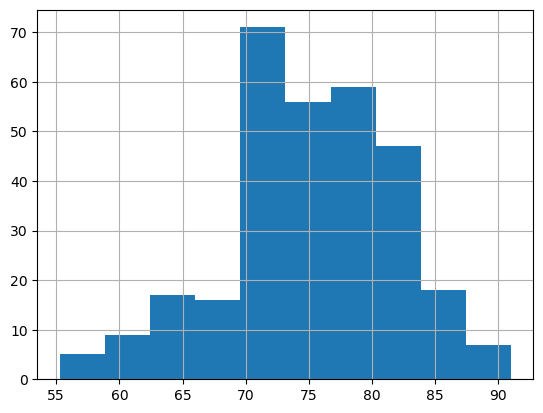

In [45]:
# --- Checking Age column
print(train_dataset['Age'].hist())
plt.show()
# Not a normal distribution

In [46]:
# --- Checking Sex column
print(train_dataset['Sex'].value_counts(normalize=True))
# Not quite balanced

Sex
1    0.567213
0    0.432787
Name: proportion, dtype: float64


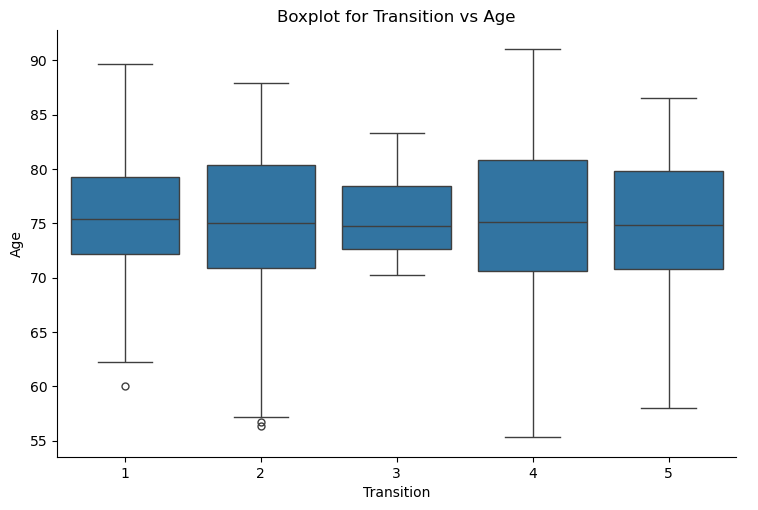

In [47]:
# --- Understanding the relationship between Age and Transition
sns.catplot(x="Transition", y="Age", data=train_dataset, kind="box", aspect=1.5)
plt.title("Boxplot for Transition vs Age")
plt.show()

In [48]:
# --- Treating outliers
# Outliers should be converted to the closest bound

print(f"DS SHAPE\n{train_dataset.shape}\n")

changes_count = 0

for col in train_dataset.columns:
    if col not in ['Transition', 'ID']:
        median = train_dataset[col].median()
        q1 = train_dataset[col].quantile(0.25)
        q3 = train_dataset[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Count outliers before replacing them
        changes_count += ((train_dataset[col] < lower_bound) | (train_dataset[col] > upper_bound)).sum()
        changes_count += ((test_dataset[col] < lower_bound) | (test_dataset[col] > upper_bound)).sum()

        # Replace outliers with the median
        # train_dataset[col] = train_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
        # test_dataset[col] = test_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

        # Replace outliers with the closest bound
        train_dataset[col] = train_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
        test_dataset[col] = test_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

print(f"TOTAL NUMBER OF CHANGES MADE: {changes_count}\n")
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 1888)

TOTAL NUMBER OF CHANGES MADE: 26068

DS SHAPE
(305, 1888)


In [49]:
# --- Dropping more constant features
# Outlier treatment creates more constant features

columns_to_exclude = train_dataset.columns[(train_dataset == train_dataset.iloc[0]).all()]
print(f"COLUMNS TO BE EXCLUDED:\n{columns_to_exclude.tolist()}\n")
train_dataset = train_dataset.drop(columns=columns_to_exclude)

COLUMNS TO BE EXCLUDED:
['lbp-2D_firstorder_InterquartileRange', 'lbp-2D_firstorder_Median']



In [50]:
# --- Standardizing data
# Using the same scaler for both datasets

scaler = StandardScaler()
columns_to_scale = train_dataset.drop(columns=['Transition']).columns
train_dataset[columns_to_scale] = scaler.fit_transform(train_dataset[columns_to_scale])
test_dataset[columns_to_scale] = scaler.transform(test_dataset[columns_to_scale])

In [51]:
# Add an 'oversampled' column to the dataset with 'NO' values
# This will be used to guarantee oversampling data is not used in testing
oversampled_column = pd.Series('NO', index=train_dataset.index, name='oversampled')
train_dataset = pd.concat([train_dataset, oversampled_column], axis=1)

In [52]:
# Checking number of samples per class
train_dataset['Transition'].value_counts()

Transition
1    96
5    71
4    68
2    60
3    10
Name: count, dtype: int64

In [53]:
# --- Oversampling data
### Oversampling should be done after standardizing but before feature selection and dimensionality reduction

print(f"DS SHAPE\n{train_dataset.shape}\n")
print("CLASS DISTRIBUTION BEFORE SMOTE OVERSAMPLING:\n")
print(train_dataset['Transition'].value_counts())

# Split the dataset into features and target
X = train_dataset.drop(columns=['Transition', 'oversampled'])
y = train_dataset['Transition']

# Identify the majority class count (class '1')
majority_class_count = y.value_counts().loc[1]

# Define the sampling strategy
sampling_strategy = {2: int(y.value_counts().loc[1]),
                     3: int(y.value_counts().loc[1]*0.33),
                     4: int(y.value_counts().loc[1]),
                     5: int(y.value_counts().loc[1])
}

# Apply SMOTE with the defined strategy
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=123)
X_smote, y_smote = smote.fit_resample(X, y)

# Create a new dataframe with the oversampled data
oversampled_data = pd.concat([X_smote, y_smote], axis=1)
oversampled_data.columns = list(X.columns) + ['Transition']

# Mark the oversampled rows with 'YES' in the 'oversampled' column
oversampled_data['oversampled'] = ['YES' if idx >= len(X) else 'NO' for idx in range(len(X_smote))]

# Concatenate the new oversampled data with the original data
train_dataset = pd.concat([train_dataset, oversampled_data[oversampled_data['oversampled'] == 'YES']], ignore_index=True)

# Display the final class distribution for verification
print("\nCLASS DISTRIBUTION AFTER SMOTE OVERSAMPLING:\n")
print(train_dataset['Transition'].value_counts())

# --- Getting the number of normal and oversampled data
train_dataset['oversampled'].value_counts()

DS SHAPE
(305, 1887)

CLASS DISTRIBUTION BEFORE SMOTE OVERSAMPLING:

Transition
1    96
5    71
4    68
2    60
3    10
Name: count, dtype: int64

CLASS DISTRIBUTION AFTER SMOTE OVERSAMPLING:

Transition
1    96
2    96
4    96
5    96
3    31
Name: count, dtype: int64


oversampled
NO     305
YES    110
Name: count, dtype: int64

In [54]:
# --- Feature selection with ANOVA

print(f"DS SHAPE\n{train_dataset.shape}\n")
X = train_dataset.drop(columns=['Transition', 'oversampled'])
y = train_dataset['Transition']

f, p = f_classif(X, y)
feature_importances = pd.Series(f, index=X.columns)
print(f"MOST IMPORTANT FEATURES\n\n{feature_importances.sort_values(ascending=False).head(10)}\n")
num_features_to_keep = 200
features_to_keep = X.columns[f.argsort()[-num_features_to_keep:]]
# Keeping the selected features on the train dataset + transition column + oversampled column
X = X[list(features_to_keep)]
X = pd.concat([X, train_dataset[['Transition', 'oversampled']]], axis=1)
train_dataset = X

# Dropping the non-selected columns from the test dataset
test_dataset = test_dataset[features_to_keep]
print(f"DS SHAPE\n{X.shape}")

DS SHAPE
(415, 1887)

MOST IMPORTANT FEATURES

lbp-2D_glrlm_ShortRunEmphasis                            68.701759
wavelet-LHH_gldm_DependenceNonUniformityNormalized       68.124081
exponential_glrlm_ShortRunLowGrayLevelEmphasis           66.678232
lbp-2D_gldm_DependenceVariance                           65.599891
lbp-2D_gldm_SmallDependenceEmphasis                      62.378787
wavelet-LHH_gldm_DependenceVariance                      61.865555
wavelet-HHH_gldm_SmallDependenceEmphasis                 60.726416
wavelet-LLL_glszm_ZoneVariance                           60.018507
wavelet-LLL_glszm_LargeAreaEmphasis                      59.991679
wavelet-HHH_gldm_SmallDependenceHighGrayLevelEmphasis    59.141784
dtype: float64

DS SHAPE
(415, 202)


In [55]:
# --- Dimensionality reduction with PCA

X = train_dataset.drop(columns=['Transition', 'oversampled'])
y = train_dataset['Transition']
pca = PCA(n_components=150)
pca.fit(X)
data = pca.transform(X)
train_dataset_no_target = pd.DataFrame(data)
train_dataset = pd.concat([train_dataset_no_target, train_dataset['Transition'], train_dataset['oversampled']], axis=1)

data_test = pca.transform(test_dataset)
test_dataset = pd.DataFrame(data_test)

In [56]:
# --- Dimensionlity Reduction with UMAP

'''
X = train_dataset.drop(columns=['Transition', 'oversampled'])
y = train_dataset['Transition']
umap = UMAP(
    n_components=50, 
    n_neighbors=50,
    min_dist=0.5,
    metric='euclidean',
    random_state=42,
    )

X_umap = umap.fit_transform(X)
train_dataset_no_target = pd.DataFrame(X_umap)
train_dataset = pd.concat([train_dataset_no_target, train_dataset['Transition'], train_dataset['oversampled']], axis=1)

data_test = umap.transform(test_dataset)
test_dataset = pd.DataFrame(data_test)
'''

"\nX = train_dataset.drop(columns=['Transition', 'oversampled'])\ny = train_dataset['Transition']\numap = UMAP(\n    n_components=50, \n    n_neighbors=50,\n    min_dist=0.5,\n    metric='euclidean',\n    random_state=42,\n    )\n\nX_umap = umap.fit_transform(X)\ntrain_dataset_no_target = pd.DataFrame(X_umap)\ntrain_dataset = pd.concat([train_dataset_no_target, train_dataset['Transition'], train_dataset['oversampled']], axis=1)\n\ndata_test = umap.transform(test_dataset)\ntest_dataset = pd.DataFrame(data_test)\n"

In [57]:
## --- Checking feature importance for the engineered features
#
#X = train_dataset.drop(columns=['Transition', 'oversampled'])
#y = train_dataset['Transition']
#
## Use RandomForest for feature importance
#rf = RandomForestClassifier(n_estimators=100, random_state=123)
#rf.fit(X, y)
#importances = rf.feature_importances_
#importance_indices = importances.argsort()[::-1]
#top_features = X.columns[importance_indices[:20]]
#top_importances = importances[importance_indices[:20]]
#features_to_keep = X.columns[importance_indices]
#
#feature_names = ['volume', 'distance', 'x', 'y', 'z', 'width', 'height', 'depth', 'x_center', 'y_center', 'z_center']
#
#print("20 MORE IMPORTANT FEATURES:\n")
#for i, (feature, importance) in enumerate(zip(top_features, top_importances), start=1):
#  print(f"{i}. {feature} - Importance: {importance:.4f}")
#
#print("\nOUR INTRODUCED FEATURES AND IMPORTANCES:\n")
#for feature in feature_names:
#    if feature in X.columns:
#        feature_index = list(X.columns).index(feature)
#        rank = np.where(importance_indices == feature_index)[0][0] + 1  # Ranking começa em 1
#        importance_value = importances[feature_index]  # Valor exato da importância
#        print(f"Ranking of '{feature}': {rank} out of {len(importance_indices)} (Importance: {importance_value:.4f})")
#    else:
#        print(f"Feature '{feature}' is not present in the dataset.")

In [58]:
# Guaranteeing all columns are shown on .head
pd.set_option('display.max_columns', None)

train_dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,Transition,oversampled
0,-6.039449,1.385087,2.763819,2.022171,1.459927,0.277295,2.506582,-0.799915,-1.102328,0.130667,-0.174392,-0.087790,0.021433,0.014163,-0.538604,1.027167,1.324749,0.280950,-0.668352,0.063671,-0.005373,0.189272,-0.552229,0.279041,0.148137,0.282876,0.013283,0.116463,-0.666441,0.135285,-0.719869,0.247775,-0.087851,-0.636719,-0.152233,-0.111534,-0.163107,0.176641,-0.070895,0.389964,0.202117,-0.220975,-0.060373,0.140195,-0.049402,-0.142653,-0.505057,-0.074442,0.070659,0.081243,0.146920,-0.274801,-0.179554,0.237899,-0.050207,0.170461,0.079722,0.101364,0.209030,0.162036,-0.143575,-0.001997,0.136860,-0.057910,-0.081438,-0.191010,-0.110022,-0.102656,-0.123760,-0.164962,0.186447,-0.178314,0.186857,-0.105101,0.011856,-0.075237,0.060863,-0.223165,0.027715,-0.230112,-0.054034,-0.007789,-0.081797,0.006380,0.081552,-0.066329,0.100045,0.084220,0.059067,0.035641,-0.040161,0.061350,-0.013664,-0.034568,0.042404,-0.134597,0.040431,0.070829,-0.016763,-0.015591,-0.127316,0.065515,0.021869,-0.029235,0.114993,-0.017398,-0.071749,-0.026513,-0.039591,0.119081,0.021391,-0.038130,0.059285,0.031511,-0.024537,0.036589,0.008133,0.022293,0.106632,0.013482,-0.005938,0.010087,0.028463,-0.003990,-0.011083,0.019146,-0.021262,-0.031348,-0.007631,-0.027688,0.039221,-0.031290,-0.001328,0.035640,-0.026302,0.011819,-0.029468,-0.001858,-0.009341,0.027626,-0.033059,-0.004470,-0.020793,-0.021503,-0.010408,0.000307,0.009388,0.020528,0.004272,0.005504,1,NO
1,-16.836062,0.096166,-0.442788,-1.873758,-1.322590,2.534752,0.137490,1.746467,0.712506,-0.915187,-0.519537,-1.164263,-0.967119,-0.685827,-0.679637,0.087808,0.135446,-1.373017,-0.210141,-2.332851,1.161483,1.198677,-0.597769,0.680623,0.415320,0.651672,-0.003369,-0.229764,-0.269764,-0.384707,0.149432,-0.191766,0.135397,0.126345,0.462806,-0.145944,-0.350065,0.259672,-0.055475,-0.069696,0.025554,0.031505,0.164912,0.010089,0.056286,0.028203,-0.278930,0.076213,0.312142,-0.035950,0.227289,-0.001585,-0.155988,-0.026594,-0.224176,-0.479958,0.237798,0.219471,0.573603,-0.117511,0.188839,-0.117798,0.230058,0.103194,-0.231099,-0.062837,-0.071383,0.044472,0.086790,0.040938,-0.161076,0.052370,0.190868,0.210159,-0.094999,-0.095592,-0.046313,0.206116,-0.035667,0.063421,-0.006968,-0.029120,-0.046244,0.018984,0.042367,-0.016789,-0.004781,-0.057976,-0.067150,0.054660,0.035576,0.072751,0.086958,0.047197,-0.100154,-0.079728,-0.123027,-0.029628,-0.030694,-0.022517,-0.016965,0.026484,-0.028390,0.044582,0.046622,0.040595,0.060502,-0.011078,0.033813,0.003480,0.012369,-0.030278,-0.012319,0.032838,0.073455,0.051920,0.095281,-0.009689,0.025913,-0.034400,0.077081,-0.040276,0.042279,-0.006033,-0.032882,0.001988,-0.009188,-0.005489,0.039263,0.013709,-0.018845,-0.013695,-0.055556,-0.041436,-0.020231,-0.009426,-0.036498,-0.000983,-0.013692,-0.035778,0.024023,0.011147,0.005487,0.013869,0.006234,0.006956,0.003760,0.014635,-0.011993,0.007198,1,NO
2,21.076154,10.871293,-4.741499,2.160282,-0.832219,-2.295569,0.610011,-0.692368,-1.432629,-1.170701,0.437685,-1.328753,-0.655503,0.235568,1.148069,-1.591131,-1.091195,0.576343,0.101185,-0.006711,-0.800216,0.527884,0.112094,0.305872,-0.214161,0.185858,-0.720092,0.186196,0.389767,0.033899,0.987439,0.440448,-0.060670,0.207902,-0.014684,-0.808620,0.188515,0.134765,0.871334,0.619610,-0.340487,0.139101,-0.347122,0.079019,0.750936,-0.361064,-0.413790,0.650457,-0.947839,0.043934,-0.094808,0.017440,-0.035456,-0.489938,0.201040,-0.254485,0.167646,0.131448,0.252153,0.218285,-0.225497,-0.121493,0.179253,-0.397206,-0.316282,

In [59]:
test_dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149
0,1.871221,2.267460,1.017153,2.381157,-1.648288,-1.115241,0.574180,-1.833980,-0.504151,-1.028010,-0.297018,2.670786,0.513107,-0.759523,0.958454,0.374372,-0.933857,0.523130,0.215210,0.045755,-0.495511,-0.362054,-1.126415,0.199125,0.251136,0.522737,0.262056,-1.038508,0.699252,0.007830,0.408999,0.438990,0.015484,0.332780,0.590983,0.393497,-0.709329,0.424872,-0.332649,0.220942,0.076388,0.040641,-0.409035,0.083831,-0.130067,0.406122,-0.120800,-0.121379,-0.126690,-0.011493,-0.404741,-0.098340,-0.104540,0.292462,0.295491,-0.028725,-0.076036,0.310504,0.080914,-0.022207,0.003531,0.287546,0.124912,0.384994,0.322418,0.118083,0.088321,0.387109,-0.125790,-0.060014,0.047031,-0.030732,0.039591,-0.144256,-0.055584,0.260118,0.055041,0.033595,0.043292,-0.218636,-0.153587,-0.049547,0.042820,-0.013687,0.020533,0.004309,0.106443,-0.066507,-0.070213,-0.001854,-0.172963,-0.049124,-0.071261,0.045868,-0.082868,-0.043302,-0.011589,0.002902,0.116200,-0.051225,-0.032862,0.027462,0.087959,-0.037009,-0.046832,-0.085176,0.020828,-0.026181,0.031513,-0.038199,-0.037132,-0.028406,0.009001,-0.015671,0.041042,-0.105619,0.087418,-0.067360,0.010460,-0.026622,0.044628,-0.008940,-0.044787,-0.034121,-0.040664,-0.062637,-0.023853,-0.059880,-0.012177,0.039889,0.018964,-0.049187,-0.060082,0.039816,0.021075,-0.016749,0.033145,-0.003588,0.001818,0.013194,0.046386,0.009007,-0.022617,-0.010492,-0.019474,0.008820,0.034023,0.007671,0.016901,-0.013992
1,-13.736048,3.486244,-0.466517,-3.018519,-0.328625,1.340152,-1.588833,1.363108,0.083204,-1.013564,-0.247105,0.053863,-0.314723,-0.983892,-0.359281,-0.366884,0.703910,-0.799747,1.134919,-0.414037,-0.286388,0.695971,-0.159117,0.659103,1.043098,-0.850408,0.044285,0.695027,0.787695,-0.220670,0.102465,0.502965,0.129554,-0.515349,0.019492,0.128652,0.354915,-0.199493,0.441290,-0.185403,-0.068763,0.054444,-0.070062,0.006868,0.181673,0.443533,0.605035,0.483241,-0.356199,-0.323827,-0.026149,0.175647,0.289418,-0.230707,0.149337,-0.114854,0.045869,0.107404,-0.251794,-0.410610,0.380869,0.021891,0.035331,-0.251738,-0.292177,-0.229979,0.125493,0.205885,-0.144444,0.136749,0.022528,-0.181564,0.059014,0.083796,0.000744,0.123007,-0.022848,0.110176,0.070743,0.181780,0.077198,0.074239,0.012882,-0.189854,0.161480,0.024694,0.032294,-0.142690,0.034185,-0.116920,0.170834,-0.189255,0.123712,-0.063475,0.113193,-0.039021,0.068019,-0.034309,-0.034761,0.073988,-0.031746,0.079079,0.040964,-0.158366,-0.148012,-0.121650,-0.043489,0.112550,0.029627,0.032404,0.130168,0.104565,0.068682,0.096560,0.037417,0.013429,0.032319,0.120241,-0.038619,-0.000269,-0.000379,0.073710,0.013298,0.004565,0.037397,0.097803,-0.078050,0.029324,0.086542,-0.009271,-0.032790,0.049328,0.090177,0.004621,-0.059050,-0.023683,-0.002356,0.006154,-0.032426,-0.016106,-0.001121,0.017763,-0.021096,-0.019102,0.002590,-0.042582,-0.018071,-0.036740,-0.013666,0.020896
2,-5.398701,4.147966,0.660730,1.116366,4.921013,0.889536,-0.165305,-0.741854,-0.484679,-0.325474,0.273138,-0.908462,0.422052,-0.428503,0.592189,-0.398913,0.121745,-0.388920,-0.125235,0.832674,-0.569329,-0.020897,0.423294,-0.566828,-0.027747,-0.207380,0.845019,0.204207,0.199387,0.096151,-0.492150,-0.345743,0.463846,0.154956,-0.052272,-0.299904,0.251008,0.438510,0.211217,-0.172689,0.232006,0.675851,0.028115,0.092104,0.324066,0.556478,0.027686,0.314118,0.033040,-0.343833,-0.023315,-0.051886,0.449785,-0.003142,-0.094127,-0.133053,0.036774,-0.173458,-0.227601,0.245959,0.005745,0.141382,-0.035373,-0.079894,0.263786,-0.014020,-0.035350,-0.039339,0.058626,0.104185,

In [60]:
# --- Saving the treated datasets
train_dataset.to_csv('data/train_dataset.csv', index=False)
test_dataset.to_csv('data/test_dataset.csv', index=False)